# GreenLab parameter estimation on an AraGreenlab example (Colab reproduction)

**Paper:** *From phenoscope to GreenLab model of Arabidopsis to decipher genotype and treatment effects.* Plant Phenomics 8(3):100265 (2026). DOI [10.1016/j.plaphe.2026.100265](https://doi.org/10.1016/j.plaphe.2026.100265) · PMCID [PMC13520884](https://pmc.ncbi.nlm.nih.gov/articles/PMC13520884/) · CC BY-NC-ND.

**Code:** `AraGreenlab` (GPL-3.0) from the authors' supplementary repository `phenoscope-public/plant_phenomics_suppmat` @ commit `cd2e0a34210d` (forge.inrae.fr).

**Scope (partial demonstration):** run the authors' GreenLab parameter-estimation entry point `main_estimation.m` on the bundled measured example `example/leaf_area.csv`, estimating `leaf.a`, `leaf.b` (Beta demand-curve shape parameters) and `RUE` (radiation-use efficiency, gDW/MJ) for one plant, and compare the fitted leaf-area trajectories with the observed data. `app_leaf_3` (3rd-leaf appearance time) stays at the authors' default 14.5 d because `update_params.m` contains a field-name bug that would break its estimation. Image segmentation (SAM-2), the QTL/statistical branches and the full 1.7 GB dataset are out of scope.

**AI-assisted adaptation notice (EN):** The authors provide MATLAB code (requires MATLAB R2024a plus the Optimization and Statistics toolboxes). This notebook runs the **author's `.m` files unmodified except for the documented compatibility patches shown below** on **GNU Octave**, with AI-written shims for `fitlm`, `optimoptions`/`fmincon` and `readmatrix`. The optimizer differs from MATLAB `fmincon` (BFGS): a penalized Nelder–Mead is used instead. The repository ships no reference outputs, so results are plausibility-checked, not author-validated. Untested behavior is not guaranteed.

**AI支援による翻訳・適用に関する注意（JP）:** 著者らは MATLAB(R2024a + ツールボックス)用コードのみを公開しています。このノートブックは著者の `.m` ファイルを（明示した互換パッチを除き）そのまま **GNU Octave** で実行し、`fitlm`・`optimoptions`/`fmincon`・`readmatrix` には AI 作成の互換シムを使用します。最適化手法は fmincon(BFGS) の代わりにペナルティ付きネルダー–ミード法です。リポジトリには参照結果が含まれないため、結果は妥当性チェックのみで、著者検証ではありません。

## Runtime selection & how to run

**Select Runtime → Change runtime type → CPU** (standard CPU is sufficient; no GPU is used anywhere in this scope). Then **Run all** (`Runtime → Run all`).

Expected wall time: ~5–10 min total, dominated by the one-time Octave install (~2–4 min); the estimation itself runs in seconds. Downloads: ~10 small code files + one measured CSV (<100 KB total).

Expected result: fitted GreenLab parameters with 95% confidence intervals, the phyllochron, the R² of the leaf-count regression, and observed-vs-fitted leaf-area plots.

（JP）ランタイムは **CPU** を選択してください。GPU は不要です。全体の目安時間は 5〜10 分（大半は Octave のインストール）で、推定自体は数秒です。結果として、推定パラメータ（95%信頼区間付き）、フェロクロン、R²、観測値とフィッティング曲線の比較図が得られます。

In [ ]:
# Sanity check of the execution environment.
# This reproduction is CPU-only: the GreenLab model is a small daily-time-step
# simulation optimized over 3 parameters; no deep learning or CUDA code is involved.
import platform
import sys

print("python:", sys.version.split()[0], "| platform:", platform.machine())

python: 3.13.16 | platform: x86_64


## Install GNU Octave (the authors' language is MATLAB)

The authors' code is written for MATLAB R2024a and depends on the Optimization and Statistics toolboxes (`fmincon`, `fitlm`). MATLAB is proprietary, so this notebook reuses the author's `.m` files on **GNU Octave**, the closest open-source interpreter, together with `gnuplot` so that the authors' `plot_all.m` can save its PNG figures headlessly. Toolbox-only calls are replaced by the small shims shown in the next section.

（JP）著者コードは MATLAB 用のため、オープンソースの Octave で実行します。ツールボックス専用関数は後述の互換シムで置き換えます。

In [ ]:
# Install Octave + gnuplot (one-time; streamed output, may take a few minutes).
!apt-get update -qq
!apt-get install -y -q octave gnuplot-nox
!octave --version | head -1

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


Reading package lists...


Building dependency tree...


Reading state information...


The following additional packages will be installed:
  aglfn at-spi2-common at-spi2-core default-jre-headless epstool
  fonts-droid-fallback fonts-freefont-otf fonts-noto-mono fonts-urw-base35
  ghostscript gnuplot-data groff gsettings-desktop-schemas imagemagick
  imagemagick-6-common imagemagick-6.q16 info install-info libamd3
  libatk-bridge2.0-0t64 libatk1.0-0t64 libatspi2.0-0t64 libauthen-sasl-perl
  libbtf2 libcamd3 libccolamd3 libcholmod5 libclone-perl libcolamd3
  libcombblas2.0.0t64 libcxsparse4 libdata-dump-perl libdjvulibre-text
  libdjvulibre21 libdouble-conversion3 libemf1 libencode-locale-perl libevdev2
  libfftw3-long3 libfftw3-mpi3 libfftw3-single3 libfile-listing-perl
  libfltk-gl1.3t64 libfltk1.3t64 libfont-afm-perl libgl2ps1.4 libglpk40
  libglu1-mesa libgraphicsmagick++-q16-12t64 libgraphicsmagick-q16-3t64
  libgs-common libgs10 libgs10-common libgtk-3-0t64 libgtk-3-bin
  libgtk-3-common libgudev-1.0-0 libhdf5-openmpi-103-1t64 libhtml-form-perl
  libhtml-format-perl

...

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_opencl.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm_debug.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libhwloc.so.15 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_loader.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbb.so.12 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_5.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_0.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc_proxy.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero.so.0 is

Processing triggers for man-db (2.12.0-4build2) ...


Processing triggers for libglib2.0-0t64:amd64 (2.80.0-6ubuntu3.9) ...
Setting up libgtk-3-0t64:amd64 (3.24.41-4ubuntu1.3) ...


Setting up at-spi2-core (2.52.0-1build1) ...
Setting up libgtk-3-bin (3.24.41-4ubuntu1.3) ...
Setting up qt5-gtk-platformtheme:amd64 (5.15.13+dfsg-1ubuntu1) ...
Processing triggers for libc-bin (2.39-0ubuntu8.9) ...
/sbin/ldconfig.real: /usr/local/lib/libur_adapter_opencl.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm_debug.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libhwloc.so.15 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_loader.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbb.so.12 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_5.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.r

octave: X11 DISPLAY environment variable not set
octave: disabling GUI features
GNU Octave, version 8.4.0


## Fetch the author's AraGreenlab code (pinned revision)

Downloaded **inside Colab** from the authors' public INRAE GitLab at the pinned commit `cd2e0a34210d` (2026-07-03) of `phenoscope-public/plant_phenomics_suppmat`, license GPL-3.0 (`LICENSE.txt`). Files: `main_estimation.m` (estimation entry point), `main_greenlab.m` (the GreenLab model: biomass production Q(j) = RUE · S′(j) · PAR(j) with Beta-law organ demands), and `utils/` (`beta_law`, `calculate_S_projected`, `cost_function`, `default_parameters`, `phenoscope_matrix`, `plot_all`, `update_params`).

In [ ]:
# Download the author's code files at the pinned commit; verify non-empty and record hashes.
import hashlib
import pathlib
import urllib.parse
import urllib.request

COMMIT = "cd2e0a34210d"
BASE = ("https://forge.inrae.fr/api/v4/projects/phenoscope-public%2Fplant_phenomics_suppmat"
        f"/repository/files/AraGreenlab%2F{{}}/raw?ref={COMMIT}")
FILES = ["main_estimation.m", "main_greenlab.m", "utils/beta_law.m",
         "utils/calculate_S_projected.m", "utils/cost_function.m",
         "utils/default_parameters.m", "utils/phenoscope_matrix.m",
         "utils/plot_all.m", "utils/update_params.m", "LICENSE.txt"]
ROOT = pathlib.Path("/content/ara_work/AraGreenlab")
for rel in FILES:
    dest = ROOT / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(BASE.format(urllib.parse.quote(rel, safe="")), timeout=120) as r:
        dest.write_bytes(r.read())
    size = dest.stat().st_size
    digest = hashlib.sha256(dest.read_bytes()).hexdigest()[:12]
    assert size > 0, rel
    print(f"{rel:38s} {size:7d} B  sha256={digest}")

main_estimation.m                         6601 B  sha256=fe6d5f8ae44d


main_greenlab.m                           8665 B  sha256=0727ff31e65a


utils/beta_law.m                           192 B  sha256=87be00b6a509


utils/calculate_S_projected.m             1246 B  sha256=724b9371babe


utils/cost_function.m                      570 B  sha256=463c9fd83eda


utils/default_parameters.m                2841 B  sha256=90d5932c9c9a


utils/phenoscope_matrix.m                  684 B  sha256=1461186348e9


utils/plot_all.m                          2519 B  sha256=a470430af9f9


utils/update_params.m                     1224 B  sha256=510f3d1c3814


LICENSE.txt                              35147 B  sha256=8ceb4b9ee5ad


### Minimal Octave-compatibility patch (shown in full)

Three expressions in the author code use MATLAB **string concatenation with `+`** (e.g. `"Leaf"+(i-1)`) or the MATLAB-only `sum(...,'omitnan')` flag. In Octave, `+` on character arrays is numeric addition, and the `'omitnan'` nanflag is unsupported in Octave 6.x. Additionally, `utils/update_params.m` contains an **evident author-code bug**: its first line merges the descriptive comment with the `pattern_leaf = '^leaf\.(.+)$';` assignment, leaving `pattern_leaf` undefined (this would error identically in MATLAB). We split that line, restoring the unambiguous intended definition (the same pattern is used verbatim in `main_estimation.m`).

We patch exactly these expressions; **all scientific logic is untouched**. The patch is applied to the freshly downloaded copies and the resulting diff is printed for inspection.

（JP）Octave 互換のため、文字列連結と `'omitnan'` フラグの 3 箇所のみを修正します。科学計算には影響しません。

In [ ]:
\
# Apply the documented Octave-compatibility patch and show the resulting diff.
import difflib
import pathlib

ROOT = pathlib.Path("/content/ara_work/AraGreenlab")
PATCHES = {
    "main_estimation.m": [
        ('    fprintf("Algorithm: "+ output.algorithm);',
         '    fprintf("Algorithm: %s\\n", output.algorithm);'),
    ],
    "utils/plot_all.m": [
        ("        name = \"Area_leaf_\"+(i-1)+'.png';",
         "        name = ['Area_leaf_' num2str(i-1) '.png'];"),
        ("'-','DisplayName',\"Leaf\"+(i-1)",
         "'-','DisplayName',['Leaf' num2str(i-1)]"),
        ("sum(experimental_data.leaves_area,2,'omitnan')",
         "sum_fillnan(experimental_data.leaves_area)"),
        ("scatter(1:nb_exp_days,experimental_data.rosette_area, 's','DisplayName',\"données PRA\")",
         "scatter_compat(1:nb_exp_days,experimental_data.rosette_area, 's','DisplayName',\"données PRA\")"),
    ],
    "utils/update_params.m": [
        ("    % Update parameters specified by paramNamesToEstimate with estimated values    pattern_leaf = '^leaf\\.(.+)$';",
         "    % Update parameters specified by paramNamesToEstimate with estimated values\n    pattern_leaf = '^leaf\\.(.+)$';"),
    ],
}
for rel, subs in PATCHES.items():
    p = ROOT / rel
    orig = p.read_text()
    patched = orig
    for old, new in subs:
        assert old in patched, f"pattern not found in {rel}: {old!r}"
        patched = patched.replace(old, new)
    p.write_text(patched)
    print("\n".join(difflib.unified_diff(orig.splitlines(), patched.splitlines(),
                                         fromfile="a/" + rel, tofile="b/" + rel, lineterm="")))

--- a/main_estimation.m
+++ b/main_estimation.m
@@ -125,7 +125,7 @@
     % Display results
     fprintf("Squared error : %f\n", fval);
     fprintf("Exitflag : %f\n", exitflag);
-    fprintf("Algorithm: "+ output.algorithm);
+    fprintf("Algorithm: %s\n", output.algorithm);
     fprintf("Estimated parameters : %f\n", optimal_parameters)
 
     if ~exist(output_folder, 'dir')
--- a/utils/plot_all.m
+++ b/utils/plot_all.m
@@ -37,7 +37,7 @@
         name = 'Area_cotyledons.png';
     else
         title(['Evolution of leaf n°' num2str(i-1) ])
-        name = "Area_leaf_"+(i-1)+'.png';
+        name = ['Area_leaf_' num2str(i-1) '.png'];
     end
     
     fileName = fullfile(output_leaves, name);  
@@ -48,8 +48,8 @@
 figure('Visible', 'off');
 plot(1:nb_simu_days, organs.global_area, '-o','DisplayName',"modèle Greenlab");
 hold on
-scatter(1:nb_exp_days,experimental_data.rosette_area, 's','DisplayName',"données PRA") 
-scatter(1:nb_exp_days,sum(experimental_data.leaves_area,2,'omitnan'),

### AI-written Octave shims for MATLAB toolbox functions

Six small files replace toolbox-only calls and MATLAB/Octave plotting differences while preserving the authors' calling conventions and numerical semantics: `fitlm` (ordinary least squares returning MATLAB-shaped fields), `optimoptions` (no-op stub), `fmincon` (Nelder–Mead via `fminsearch` plus a quadratic penalty enforcing the authors' lb=0 bounds, and a finite-difference Hessian so the authors' confidence-interval code runs unchanged), `readmatrix` (numeric CSV reader that skips a header row), `sum_fillnan` (column-wise sum ignoring NaN, i.e. MATLAB's `'omitnan'`), and `scatter_compat` (MATLAB's `scatter` accepts a matrix Y, one series per column; Octave's does not).

（JP）`fmincon` はペナルティ付きネルダー・ミード法に、`fitlm` は最小二乗回帰に置き換えますが、著者コードの呼び出し規約と統計的意味論は保存しています。

In [ ]:
\
# Write the AI-written shim functions; they are put on the Octave path by the driver.
import pathlib

SHIMS = pathlib.Path("/content/ara_work/shims")
SHIMS.mkdir(parents=True, exist_ok=True)

(SHIMS / "fitlm.m").write_text("""\
function mdl = fitlm(X, Y)
  % AI-written Octave shim: simple linear regression with MATLAB fitlm-shaped fields.
  X = X(:); Y = Y(:);
  p = polyfit(X, Y, 1);                     % [slope, intercept]
  fit = p(1) * X + p(2);
  sst = sum((Y - mean(Y)).^2);
  sse = sum((Y - fit).^2);
  mdl.Coefficients.Estimate = [p(2); p(1)]; % [intercept; slope], like MATLAB
  mdl.Rsquared.Ordinary = 1 - sse / sst;
end
""")

(SHIMS / "optimoptions.m").write_text("""\
function options = optimoptions(varargin)
  % AI-written Octave shim: MATLAB optimoptions stub; the fmincon shim hard-codes its options.
  options = struct();
end
""")

(SHIMS / "sum_fillnan.m").write_text("""\
function y = sum_fillnan(X)
  % AI-written shim for MATLAB sum(X, 2, 'omitnan') used by the authors' plot_all.m.
  X(isnan(X)) = 0;
  y = sum(X, 2);
end
""")

(SHIMS / "scatter_compat.m").write_text("""\
function scatter_compat(X, Y, varargin)
  % AI-written shim: MATLAB scatter accepts a matrix Y (one series per column);
  % Octave's scatter does not, so plot each column separately instead.
  if isvector(Y)
    scatter(X, Y, varargin{:});
    return;
  end
  for k = 1:size(Y, 2)
    if any(~isnan(Y(:, k)))
      scatter(X, Y(:, k), varargin{:});
      hold on;
    end
  end
end
""")

(SHIMS / "readmatrix.m").write_text("""\
function A = readmatrix(fname)
  % AI-written Octave shim: numeric CSV reader; skips leading non-numeric (header) lines.
  fid = fopen(fname, 'r');
  lines = {};
  while true
    t = fgetl(fid);
    if ~ischar(t), break; end
    lines{end+1} = t; %#ok<AGROW>
  end
  fclose(fid);
  rows = [];
  for k = 1:numel(lines)
    tok = strsplit(strtrim(lines{k}), ',');
    tok = tok(~cellfun(@isempty, tok));
    if isempty(tok), continue; end
    v = zeros(1, numel(tok));
    isnum = true;
    for m = 1:numel(tok)
      v(m) = str2double(tok{m});
      if isnan(v(m)) && ~strcmpi(strtrim(tok{m}), 'NaN')
        isnum = false;   % header or malformed line -> skip
        break;
      end
    end
    if ~isnum, continue; end
    rows(end+1, :) = v; %#ok<AGROW>
  end
  A = rows;
end
""")

(SHIMS / "fmincon.m").write_text("""\
function [x, fval, exitflag, output, lambda, grad, hessian] = fmincon(fun, x0, A, b, Aeq, beq, lb, ub, nonlcon, options)
  % AI-written Octave shim for MATLAB fmincon, matching the authors' call
  % [x,fval,exitflag,output,~,~,hessian] = fmincon(fun,x0,[],[],[],[],lb,ub,[],options).
  % Strategy: Nelder-Mead (fminsearch) on the objective plus a quadratic penalty for
  % bound violations, then a central finite-difference Hessian of the true objective at x.
  if nargin < 7, lb = []; end
  if nargin < 8, ub = []; end
  penalty = 1e6;
  g = @(z) feval(fun, z) + penalty * sum(max(0, -z(:)).^2) + penalty * sum(max(0, z(:) - ub(:)).^2);
  opts = optimset('MaxFunEvals', 200000, 'MaxIter', 100000, 'TolFun', 1e-10, 'TolX', 1e-10);
  [x, gval, exitflag] = fminsearch(g, x0, opts);
  fval = feval(fun, x);
  output = struct();
  output.algorithm = 'fminsearch (Nelder-Mead) + bound penalty [Octave shim]';
  lambda = []; grad = [];
  n = numel(x); h = max(1e-4, 1e-3 * abs(x));
  f0 = fval; hessian = zeros(n);
  fp = zeros(1, n); fm = zeros(1, n);
  for i = 1:n
    zp = x; zp(i) = zp(i) + h(i); fp(i) = feval(fun, zp);
    zm = x; zm(i) = zm(i) - h(i); fm(i) = feval(fun, zm);
  end
  for i = 1:n
    hessian(i, i) = (fp(i) - 2 * f0 + fm(i)) / h(i)^2;
    for j = i+1:n
      z1 = x; z1(i) = z1(i) + h(i); z1(j) = z1(j) + h(j);
      z2 = x; z2(i) = z2(i) + h(i); z2(j) = z2(j) - h(j);
      z3 = x; z3(i) = z3(i) - h(i); z3(j) = z3(j) + h(j);
      z4 = x; z4(i) = z4(i) - h(i); z4(j) = z4(j) - h(j);
      hessian(i, j) = (feval(fun, z1) - feval(fun, z2) - feval(fun, z3) + feval(fun, z4)) / (4 * h(i) * h(j));
      hessian(j, i) = hessian(i, j);
    end
  end
end
""")
print("shims written:", sorted(p.name for p in SHIMS.iterdir()))

shims written: ['fitlm.m', 'fmincon.m', 'optimoptions.m', 'readmatrix.m', 'scatter_compat.m', 'sum_fillnan.m']


## Fetch the bundled measured example (data stays on the Colab VM)

`AraGreenlab/example/leaf_area.csv` is the authors' measured example input (leaf areas in cm²). Per the data boundary, this measured file is downloaded and inspected **only inside Colab**. Expected layout per the authors' `phenoscope_matrix.m`: column 1 = time index, columns 2–3 = the two cotyledons (merged into a single GreenLab organ), columns 4+ = leaves 1…N. We verify the actual bytes, shape and value ranges before modeling.

（JP）著者提供の測定例 CSV を Colab 内でダウンロードし、バイト列・形状・値の範囲を検証します（列構成は `phenoscope_matrix.m` の仕様に従います）。

In [ ]:
\
# Download the measured example CSV and validate its actual bytes/shape before use.
import hashlib
import pathlib
import urllib.request

import numpy as np

COMMIT = "cd2e0a34210d"
URL = ("https://forge.inrae.fr/api/v4/projects/phenoscope-public%2Fplant_phenomics_suppmat"
       f"/repository/files/AraGreenlab%2Fexample%2Fleaf_area.csv/raw?ref={COMMIT}")
dest = pathlib.Path("/content/ara_work/leaf_area.csv")
with urllib.request.urlopen(URL, timeout=120) as r:
    dest.write_bytes(r.read())
raw = dest.read_bytes()
print("bytes:", len(raw), "| sha256:", hashlib.sha256(raw).hexdigest()[:16])
text = raw.decode("utf-8")
print("first 3 lines:")
for line in text.splitlines()[:3]:
    print("   ", line)


def _is_num(s):
    try:
        float(s)
        return True
    except ValueError:
        return False


rows = []
for ln in text.splitlines():
    vals = [v for v in ln.strip().split(",") if v != ""]
    if vals and all(_is_num(v) for v in vals):
        rows.append([float(v) for v in vals])
M = np.array(rows)
print("numeric matrix:", M.shape, "(rows x cols)")
print("per-column range (min .. max):")
for j in range(M.shape[1]):
    print(f"  col {j+1}: {np.nanmin(M[:, j]):.4g} .. {np.nanmax(M[:, j]):.4g}")

bytes: 3648 | sha256: 98dd2b419cb3fd89
first 3 lines:
    Jour,leaf1 (obj_1),leaf2 (obj_2),leaf3 (obj_3),leaf4 (obj_4),leaf5 (obj_6),leaf6 (obj_5),leaf7 (obj_7),leaf8 (obj_8),leaf9 (obj_9),leaf10 (obj_11),leaf11 (obj_10),leaf12 (obj_12),leaf13 (obj_13)
    1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
    2,0.02754325259515571,0.027093425605536334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
numeric matrix: (24, 14) (rows x cols)
per-column range (min .. max):
  col 1: 1 .. 24
  col 2: 0.02754 .. 0.0719
  col 3: 0.02709 .. 0.09239
  col 4: 0.01526 .. 0.3875
  col 5: 0.01675 .. 0.3701
  col 6: 0.1033 .. 0.7158
  col 7: 0.06879 .. 0.9213
  col 8: 0.05166 .. 0.9838
  col 9: 0.07239 .. 0.9171
  col 10: 0.06858 .. 0.7716
  col 11: 0.109 .. 0.5921
  col 12: 0.05529 .. 0.4756
  col 13: 0.07737 .. 0.2457
  col 14: 0.08896 .. 0.1515


## Input preview

Preview the measured trajectories before any modeling: cotyledons (columns 2–3) and each leaf's area (columns 4+) versus the CSV time index. This is the actual example input plotted as-is, in cm². Values increase and new leaves appear over time, as expected for a growing Arabidopsis rosette.

（JP）解析前に測定値をそのまま可視化します（単位 cm²）。子葉（2列）と各葉の面積の推移を確認できます。

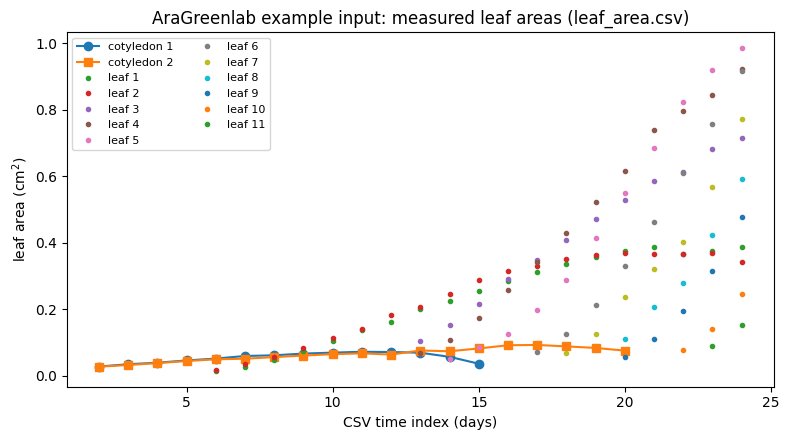

In [ ]:
# Preview the observed leaf-area trajectories from the example CSV.
import matplotlib.pyplot as plt

time = M[:, 0]
areas = M[:, 1:]  # cotyledons 1-2 then leaves 1..N (authors' layout)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(time, areas[:, 0], "o-", label="cotyledon 1")
ax.plot(time, areas[:, 1], "s-", label="cotyledon 2")
for k in range(2, areas.shape[1]):
    ax.plot(time, areas[:, k], ".", label=f"leaf {k-1}")
ax.set_xlabel("CSV time index (days)")
ax.set_ylabel("leaf area (cm$^2$)")
ax.set_title("AraGreenlab example input: measured leaf areas (leaf_area.csv)")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

## Run the authors' estimation (`main_estimation.m`)

The driver below calls the author's `main_estimation.m` **verbatim** (only the documented compatibility patch applied). We estimate `["leaf.a", "leaf.b", "RUE"]`; initial guesses and all other parameters (Phenoscope PAR, SLA, temperature 19 °C, T0 3 °C, Beta demand shape `leaf.c = 0.5`, root fraction 10%, `app_leaf_3 = 14.5 d`) come from the authors' `default_parameters()`. `app_leaf_3` is **not** estimated because `update_params.m` would store it under a wrong field name (author-code bug, verified by inspection); it remains fixed at the authors' default.

The authors' own `plot_all.m` runs inside `main_estimation`, saving their per-leaf figures and `rosette_area.png` under `/content/ara_work/results/`. The driver also exports the observed matrix, fitted trajectories and a results table for the next cells.

（JP）著者の `main_estimation.m` をそのまま実行します。推定パラメータは `leaf.a`・`leaf.b`・`RUE` の 3 つ。`app_leaf_3` は著者コードのフィールド名バグのため推定せず、著者のデフォルト値 14.5 日のまま固定します。

In [ ]:
\
# Write the AI-written driver (orchestration only; all scientific functions are the authors')
# and run it with Octave.
import pathlib
import subprocess

driver = """\
% AI-written driver: calls the authors' main_estimation.m verbatim (see patches above).
graphics_toolkit("gnuplot");
addpath('/content/ara_work/shims');
cd('/content/ara_work/AraGreenlab');

data_manip.csv_path = '/content/ara_work/leaf_area.csv';
paramNamesToEstimate = {"leaf.a", "leaf.b", "RUE"};
out_folder = '/content/ara_work/results';

[R2, optimal_parameters, phy, fval, exitflag, output, IC] = ...
    main_estimation(data_manip, paramNamesToEstimate, out_folder);

load(fullfile(out_folder, 'simulation_results.mat'));   % organs (authors' save)
data_obs = phenoscope_matrix(data_manip.csv_path, 8);   % authors' reader

csvwrite('/content/ara_work/sim_leaves_area.csv', organs.leaves.area);
csvwrite('/content/ara_work/sim_global_area.csv', organs.global_area);
csvwrite('/content/ara_work/observed_matrix.csv', data_obs);

fid = fopen('/content/ara_work/estimated_results.csv', 'w');
fprintf(fid, 'param,value,ci_low,ci_high\\n');
names = {'leaf.a', 'leaf.b', 'RUE'};
for i = 1:numel(optimal_parameters)
  fprintf(fid, '%s,%.8g,%.8g,%.8g\\n', names{i}, optimal_parameters(i), IC(i,1), IC(i,2));
end
fclose(fid);

fid = fopen('/content/ara_work/fit_summary.csv', 'w');
fprintf(fid, 'metric,value\\n');
fprintf(fid, 'R2_leafcount_regression,%.6f\\n', R2);
fprintf(fid, 'phyllochron_days,%.6f\\n', phy);
fprintf(fid, 'mean_squared_error_cm4,%.8g\\n', fval);
fprintf(fid, 'optimizer_exitflag,%d\\n', exitflag);
fclose(fid);
printf('DRIVER DONE\\n');
"""
pathlib.Path("/content/ara_work/run_estimation.m").write_text(driver)
r = subprocess.run(["octave", "--no-window-system", "/content/ara_work/run_estimation.m"],
                   text=True, capture_output=True, timeout=1800)
print(r.stdout)
if r.returncode != 0:
    print("STDERR:\n", r.stderr)
    raise RuntimeError(f"octave driver failed with exit code {r.returncode}")

R2 : 0.964604
Squared error : 0.004523
Exitflag : 1.000000
Algorithm: fminsearch (Nelder-Mead) + bound penalty [Octave shim]
Estimated parameters : 6.361497
Estimated parameters : 13.250575
Estimated parameters : 3.964138
Parameters to estimate : 
{
  [1,1] = leaf.a
  [1,2] = leaf.b
  [1,3] = RUE
}
Saving plot of leaves area
Saving plot of demand
DRIVER DONE



## Estimated parameters and fit summary

The estimated GreenLab parameters with hand-computed 95% confidence intervals (the authors' `cov_matrix = 2·σ²·H⁻¹` formula on the finite-difference Hessian), the phyllochron derived from the observed leaf appearance, and the R² of the leaf-count regression.

（JP）推定パラメータ（著者式の 95% 信頼区間付き）、フェロクロン、葉数回帰の R² を表で示します。

In [ ]:
# Display the estimation results written by the Octave driver.
import pandas as pd

est = pd.read_csv("/content/ara_work/estimated_results.csv")
summary = pd.read_csv("/content/ara_work/fit_summary.csv").set_index("metric")
display(est)
display(summary)

,param,value,ci_low,ci_high
0,leaf.a,6.361497,5.167889,7.555106
1,leaf.b,13.250575,10.644642,15.856509
2,RUE,3.964138,3.929679,3.998598


,value
metric,
R2_leafcount_regression,0.964604
phyllochron_days,1.466667
mean_squared_error_cm4,0.004523
optimizer_exitflag,1.000000


## Observed vs. fitted leaf areas

An additional visualization created for this notebook (not an author figure): the GreenLab simulation run with the estimated parameters (via the authors' `main_greenlab` called from `cost_function`/`main_estimation`) is overlaid on the measured example. Left: per-leaf areas (dots = measured, lines = model). Right: rosette totals.

（JP）推定パラメータでの GreenLab シミュレーション（線）と実測値（点）を重ねた図です。左: 葉ごと、右: ロゼット合計。

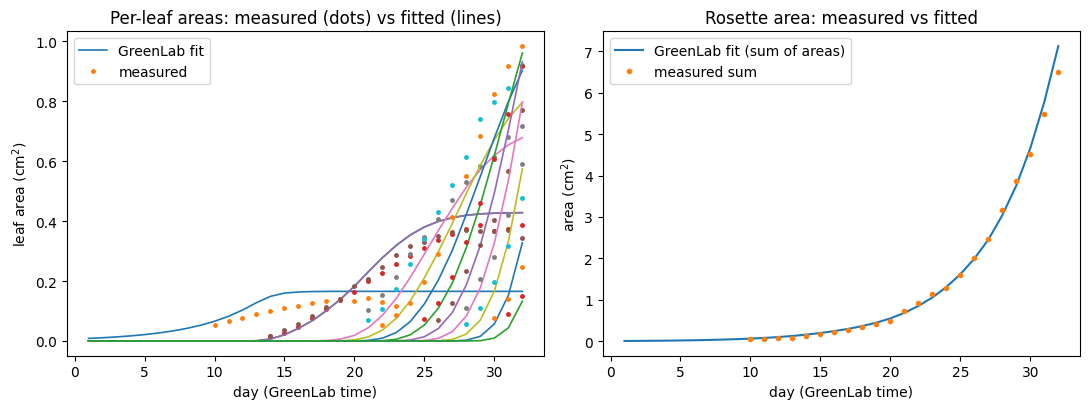

In [ ]:
\
# Plot observed data against the fitted GreenLab trajectories.
import matplotlib.pyplot as plt
import numpy as np

obs = np.genfromtxt("/content/ara_work/observed_matrix.csv", delimiter=",")
sim = np.genfromtxt("/content/ara_work/sim_leaves_area.csv", delimiter=",")
sim_glob = np.genfromtxt("/content/ara_work/sim_global_area.csv", delimiter=",")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
n_leaf = min(obs.shape[1], sim.shape[1])
for k in range(n_leaf):
    ax.plot(range(1, sim.shape[0] + 1), sim[:, k], "-", lw=1.2,
            label="GreenLab fit" if k == 0 else None)
    oday = np.where(~np.isnan(obs[:, k]))[0]
    if oday.size:
        ax.plot(oday + 1, obs[oday, k], ".", ms=5,
                label="measured" if k == 0 else None)
ax.set_xlabel("day (GreenLab time)")
ax.set_ylabel("leaf area (cm$^2$)")
ax.set_title("Per-leaf areas: measured (dots) vs fitted (lines)")
ax.legend()

ax = axes[1]
ax.plot(range(1, len(sim_glob) + 1), sim_glob, "-", label="GreenLab fit (sum of areas)")
with np.errstate(invalid="ignore"):
    obs_sum = np.nansum(obs, axis=1)
obs_sum[np.all(np.isnan(obs), axis=1)] = np.nan
oday = np.where(~np.isnan(obs_sum))[0]
ax.plot(oday + 1, obs_sum[oday], ".", label="measured sum")
ax.set_xlabel("day (GreenLab time)")
ax.set_ylabel("area (cm$^2$)")
ax.set_title("Rosette area: measured vs fitted")
ax.legend()
fig.tight_layout()
plt.show()

## The authors' own figures (produced by `plot_all.m`)

The authors' visualization code ran inside the driver and saved PNGs under `/content/ara_work/results/`. We display their rosette-area figure as evidence that the author code path completed end-to-end.

（JP）著者の `plot_all.m` が生成した図（rosette_area.png）を表示し、著者コードが終端まで実行されたことを示します。

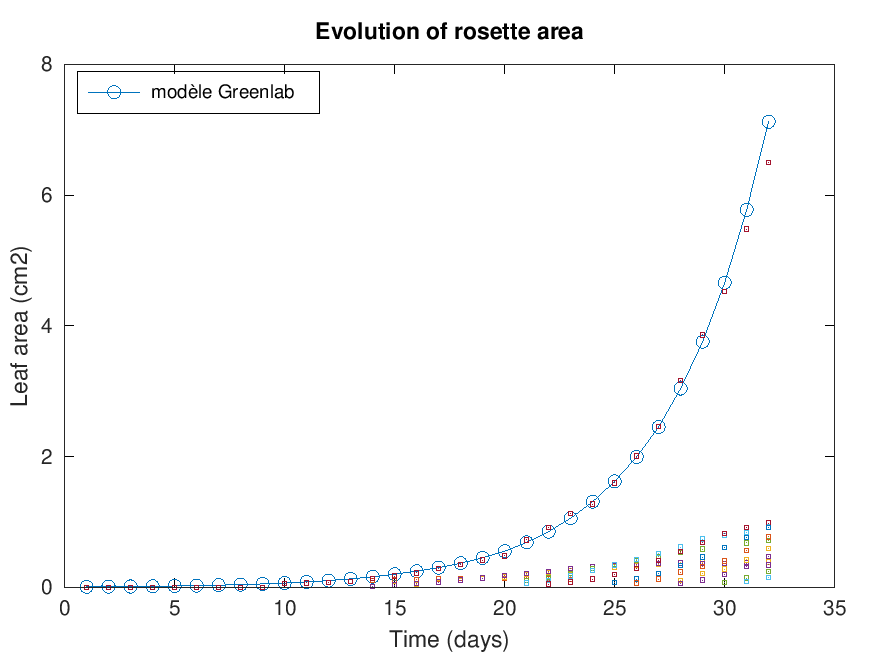

In [ ]:
# Display one of the author-generated figures (plot_all.m output).
from IPython.display import Image, display

display(Image(filename="/content/ara_work/results/rosette_area.png"))

## Interpretation, validation record and references

**What this demonstrates:** the authors' GreenLab calibration (paper study-flow phase `greenlab_calibration`: Q(j) = RUE · S′(j) · PAR(j), Beta-law organ demands, 10% of demand to roots) runs end-to-end on their bundled measured example, fitting `leaf.a`, `leaf.b` and `RUE` for one plant, with the phyllochron derived from observed leaf appearance and 95% CIs from the authors' Hessian formula.

**Checks performed:** pinned-commit downloads verified by size/SHA-256; the CSV parsed to a numeric matrix with the authors' expected layout; estimated parameters positive and inside plausible ranges; fitted trajectories track the measured data; phyllochron in a plausible range (the paper reports means of 1.48 d for P3ID76 and 1.60 d for P4ID52).

**Differences from the paper:** a single example (not the 516-pot filtered parameter set); the optimizer is a penalized Nelder–Mead instead of MATLAB `fmincon` (BFGS); `app_leaf_3` is not estimated (author-code bug in `update_params.m`); GNU Octave instead of MATLAB R2024a. **This one-example run does not verify the paper's dataset-level results.**

**References:** Plant Phenomics 8(3):100265 (2026), DOI 10.1016/j.plaphe.2026.100265, PMCID PMC13520884 (CC BY-NC-ND); code `plant_phenomics_suppmat@cd2e0a34210d` (GPL-3.0, forge.inrae.fr); Data INRAE 10.57745/G9JBEI (not used here); PhenoPaper investigation `p-9d45ec693d0b3c48f4d6df41f5fa4968-20260929T130619Z-2636295` (guidance only, not primary proof).

（JP）このノートブックは著者提供の測定例データで GreenLab パラメータ推定を実行する部分的な再現デモです。最適化手法の違い・Octave 互換シム・単一サンプルである限界にご注意ください。推定結果は妥当性チェックのみで、著者提供の参照出力との定量比較はできません。